# PCA Dimensionality Reduction and Animated K-Means Clustering

This self-contained notebook demonstrates:
1. **Extracting and Profiling** a real 4-dimensional dataset.
2. **Dimensionality Reduction (PCA)** to project data down to a visualizable 2D space.
3. **Step-by-step K-Means Clustering** applied with custom logic to trace centroids and point assignments.
4. **Animation Generation** to produce a high-quality GIF of the clustering convergence.

### Dataset Details
- **Source**: UCI Machine Learning Repository via `sklearn.datasets` (Fisher's Iris dataset, 1936).
- **Reason for Selection**: It is a public, real, strictly non-synthetic dataset containing exactly **4 numerical features**, offering an ideal, recognizable baseline for both dimensionality reduction and clustering demonstrations.

In [1]:
import os
from scipy.stats import mode
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Minimal Exploratory Data Analysis (EDA)

We load the Iris dataset and inspect its structure. It features four distinct numerical attributes: sepal length, sepal width, petal length, and petal width.

In [2]:
# Load the dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
true_labels = iris.target
target_names = iris.target_names

print(f"Dataset Shape: {df.shape} (Rows: {df.shape[0]}, Features: {df.shape[1]})")
print(f"Numerical Features: {list(df.columns)}")

# Display the first few rows purely for sanity checking
display(df.head())

Dataset Shape: (150, 4) (Rows: 150, Features: 4)
Numerical Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2. Dimensionality Reduction via PCA

Before clustering and building the 2D animation, the 4D data is centered and scaled (Z-score normalization). We then apply Principal Component Analysis (PCA) to derive the two most explanatory principal components.

In [3]:
# Standardize the features - critical for PCA to behave symmetrically
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Original Shape: {X_scaled.shape} -> PCA Output Shape: {X_pca.shape}")
print(f"Explained Variance Ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total Variance Captured: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original Shape: (150, 4) -> PCA Output Shape: (150, 2)
Explained Variance Ratio (PC1, PC2): [0.72962445 0.22850762]
Total Variance Captured: 95.81%


## 3. Step-by-Step K-Means Implementation

To build our iteration transparency, we wrap standard K-Means assignments using custom iterative logic. This explicitly computes coordinates so that we track centroid locations and label assignments **every single step** until algorithmic convergence.

In [4]:
k = 3  # Based on standard Iris classes

# 1. Initialize centroids randomly from existing dataset points
initial_indices = np.random.choice(X_pca.shape[0], k, replace=False)
centroids = X_pca[initial_indices]

history_centroids = [centroids]
history_labels = []

converged = False
iteration = 0

while not converged and iteration < 50:
    # E-step: Assign nodes to nearest cluster center using Euclidean distance
    distances = np.linalg.norm(X_pca[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    history_labels.append(labels)
    
    # M-step: Calculate new cluster centers by computing the mean cluster assignments
    new_centroids = np.array([X_pca[labels == i].mean(axis=0) if np.sum(labels == i) > 0 
                              else centroids[i] for i in range(k)])
    history_centroids.append(new_centroids)
    
    # Convergence check: Did centroids shift substantially?
    if np.allclose(centroids, new_centroids, atol=1e-5):
        converged = True
    
    centroids = new_centroids
    iteration += 1

print(f"K-Means converged after {iteration} iterations.")
print(f"Tracked {len(history_labels)} state updates for animation.")

K-Means converged after 9 iterations.
Tracked 9 state updates for animation.


## 3.5. Model Evaluation (Accuracy and Confusion Matrix)

While K-Means is unsupervised, we can map each derived cluster to the most frequent true species inside it. This allows us to calculate an accuracy score and plot a confusion matrix using `sklearn.metrics`.

K-Means Mapped Accuracy to True Species: 82.00%



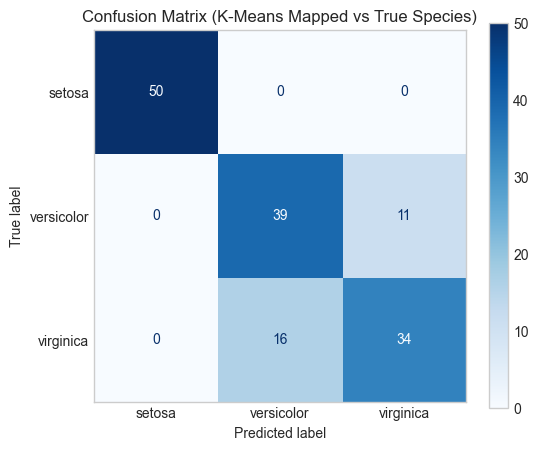

In [5]:
# Map final K-Means output clusters to their most frequent true species label
final_labels = history_labels[-1]
mapped_labels = np.zeros_like(final_labels)
cluster_to_species = {}

for i in range(k):
    mask = (final_labels == i)
    if np.any(mask):
        most_common = mode(true_labels[mask], keepdims=True)[0][0]
        mapped_labels[mask] = most_common
        cluster_to_species[i] = target_names[most_common]
    else:
        cluster_to_species[i] = f"Cluster {i}"

# Calculate unsupervised mapping accuracy
accuracy = accuracy_score(true_labels, mapped_labels)
print(f"K-Means Mapped Accuracy to True Species: {accuracy * 100:.2f}%\n")

# Display Confusion Matrix
cm = confusion_matrix(true_labels, mapped_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax_cm = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax_cm)
plt.title("Confusion Matrix (K-Means Mapped vs True Species)")
plt.grid(False)
plt.show()

## 4. Animating Iterations (GIF Output)

Using `matplotlib.animation.FuncAnimation`, we weave together our stored coordinates and labels into an animation showing point reassignment, centroid paths, and iterative shifts. The output is anchored in the repository root as `kmeans_animation.gif`.

In [10]:
# Create a figure with high DPI for quality
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
ax.set_title("K-Means Clustering Iterations", fontsize=16, fontweight='bold', pad=20)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Light base colors
dark_colors = ['#0f3b5a', '#803f07', '#165016'] # Darker shades for centroids
light_cmap = ListedColormap(['#c6dff2', '#ffdabd', '#b8f2c6']) # Pastel shades for Voronoi background

# Meshgrid for Voronoi background evaluation
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# Base plot components
scatter_points = ax.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', s=40, alpha=0.9, edgecolors='k', zorder=5)
scatter_cents = ax.scatter(history_centroids[0][:, 0], history_centroids[0][:, 1], c=dark_colors, marker='X', s=250, edgecolors='white', linewidths=2, zorder=15)

# Add Legend based on our previous mapping (Cluster ID -> Majority Species Name)
legend_patches = [Patch(facecolor=colors[i], edgecolor=dark_colors[i], label=cluster_to_species[i]) for i in range(k)]
ax.legend(handles=legend_patches, title="Species Mapping", loc='upper left', frameon=True, 
          facecolor='white', framealpha=0.9).set_zorder(20)

title_text = ax.text(0.5, 0.98, '', transform=ax.transAxes, ha='center', fontsize=12, 
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', zorder=20))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)

# Keep the grid on top of the shaded background but under data
ax.grid(True, linestyle='--', alpha=0.6, zorder=1)

arrows = []
state = {'contour': None}

def clear_contour():
    if state['contour']:
        try:
            # For matplotlib >= 3.8
            state['contour'].remove()
        except AttributeError:
            # For older matplotlib
            for coll in state['contour'].collections:
                try: coll.remove()
                except: pass
        state['contour'] = None

def init():
    scatter_cents.set_offsets(history_centroids[0])
    title_text.set_text('')
    clear_contour()
    return scatter_points, scatter_cents, title_text

def animate(i):
    frame_idx = min(i, len(history_labels) - 1)
    curr_cents = history_centroids[frame_idx]
    
    # 1: Voronoi Decision Background
    clear_contour()
        
    dist_mesh = np.linalg.norm(mesh_points[:, np.newaxis] - curr_cents, axis=2)
    mesh_labels = np.argmin(dist_mesh, axis=1).reshape(xx.shape)
    # Using zorder=0 to ensure background stays behind grid and data points
    state['contour'] = ax.contourf(xx, yy, mesh_labels, alpha=0.4, cmap=light_cmap, vmin=0, vmax=2, zorder=0)

    # 2: Point colors via corresponding cluster assignments
    labels = history_labels[frame_idx]
    c_vals = [colors[label] for label in labels]
    scatter_points.set_color(c_vals)
    scatter_points.set_edgecolors('k')
    
    # 3: Current Centroid Positions (initialized matching cluster dark_colors)
    scatter_cents.set_offsets(curr_cents)
    
    # 4: Movement Trajectory (Arrows)
    while arrows:
        arr = arrows.pop()
        arr.remove()
        
    if frame_idx > 0:
        prev_cents = history_centroids[frame_idx - 1]
        for p_cent, c_cent in zip(prev_cents, curr_cents):
            # Draw arrow pointing from previous position to the new position
            arr = ax.annotate('', xy=c_cent, xytext=p_cent,
                              arrowprops=dict(arrowstyle="->", color='#333333', lw=2, alpha=0.8, shrinkA=0, shrinkB=0),
                              zorder=10)
            arrows.append(arr)
            
    title_text.set_text(f"Iteration: {frame_idx + 1} / {len(history_labels)}")
    
    # Passing collections for Pyplot Blit update, but Blitting with Contour sets is extremely buggy on some OS.
    # To be extremely safe, we let standard rendering frame handle the updates.
    return []

total_frames = len(history_labels) + 2 

# Increase interval for a slower/smoother stepping transition
# Using blit=False is much safer when doing dynamic full-axis background contour updates over time.
anim = FuncAnimation(fig, animate, init_func=init, frames=total_frames, interval=1500, blit=False)

gif_path = '../animations/kmeans_animation.gif'
# Slower FPS increases the "hold time" natively in the gif file
anim.save(gif_path, dpi=120, writer=PillowWriter(fps=0.7))
plt.close(fig)

print(f"Successfully saved enhanced visualization exactly to: {os.path.abspath(gif_path)}")

Successfully saved enhanced visualization exactly to: d:\Git-Projects\clustering-algorithms\animations\kmeans_animation.gif
